In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import smarts_cerebellum.globals as gl


## Modulated WM volume

**note**: mod WM had convergence warning (for all groups, both left, right CST)

In [2]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'WM'

patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')

patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')


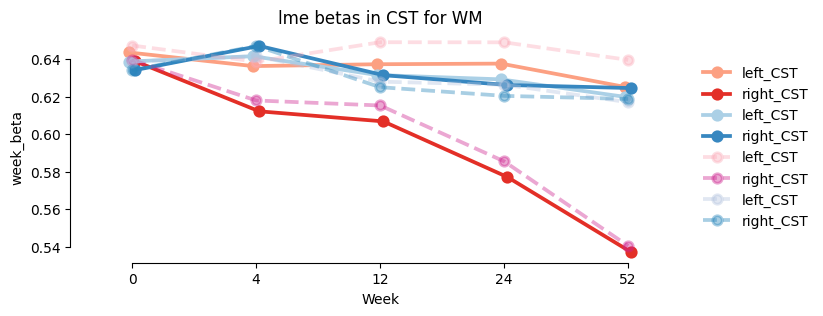

In [3]:
reds = sns.color_palette("Reds", n_colors=2)
red_purples = sns.color_palette("RdPu", n_colors = 2)
blues = sns.color_palette("Blues", n_colors=2)
blue_purples = sns.color_palette("PuBu", n_colors = 2)


fig, ax = plt.subplots(figsize=(8,3))

sns.pointplot(data = patients_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True)
sns.pointplot(data = controls_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 1, dodge = True)

sns.pointplot(data = patients_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = red_purples, alpha = 0.4, linestyle = '--')
sns.pointplot(data = controls_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = blue_purples, alpha = 0.4, linestyle = '--')


ax.set_title(f"lme betas in CST for {segment}")
ax.legend(bbox_to_anchor=(1, .5), loc = 'center left', frameon = False)

sns.despine(trim = True)
plt.show()

## T1

In [4]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'T1'

patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mean.tsv'), sep = '\t')

patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_CST_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_CST_lme.tsv'), sep = '\t')

# order weeks correctly
week_order = ['Intercept', 'Week[T.4]', 'Week[T.12]', 'Week[T.24]', 'Week[T.52]']
patients_lme['week'] = pd.Categorical(patients_lme['week'], categories = week_order, ordered = True)
controls_lme['week'] = pd.Categorical(controls_lme['week'], categories = week_order, ordered = True)

# put the ordering into the df
patients_lme = patients_lme.sort_values('week').reset_index(drop = True)
controls_lme = controls_lme.sort_values('week').reset_index(drop = True)

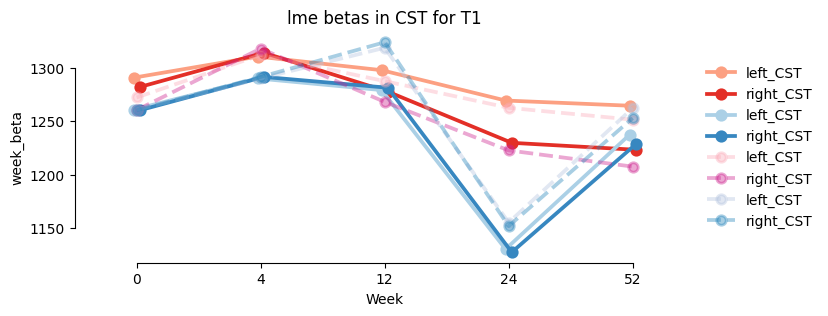

In [5]:
reds = sns.color_palette("Reds", n_colors=2)
red_purples = sns.color_palette("RdPu", n_colors = 2)
blues = sns.color_palette("Blues", n_colors=2)
blue_purples = sns.color_palette("PuBu", n_colors = 2)


fig, ax = plt.subplots(figsize=(8,3))

sns.pointplot(data = patients_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = reds, alpha = 1, dodge = True)
sns.pointplot(data = controls_lme, x = 'Week', y = 'week_beta', hue = 'regionname', palette = blues, alpha = 1, dodge = True)

sns.pointplot(data = patients_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = red_purples, alpha = 0.4, linestyle = '--')
sns.pointplot(data = controls_actual, x = 'Week', y = 'mean', hue = 'regionname', palette = blue_purples, alpha = 0.4, linestyle = '--')


ax.set_title(f"lme betas in CST for {segment}")
ax.legend(bbox_to_anchor=(1, .5), loc = 'center left', frameon = False)

sns.despine(trim = True)
plt.show()